In [29]:
# from google.colab import drive
# drive.mount('/content/drive')

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix,
    precision_recall_curve  # Add this import
)
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer

# Step 1: Data Preprocessing and Cleaning


In [31]:
def preprocess_data(filepath):
    # Load dataset
    data = pd.read_csv(filepath)

    # Clean column names
    data.columns = data.columns.str.strip().str.replace(' ', '_')

    # Handle percentage columns
    percentage_columns = ['mandala_completion', 'music_completion', 'OverallActivityCompletionRate']
    for col in percentage_columns:
        if col in data.columns:
            data[col] = (
                data[col]
                .astype(str)  # Ensure values are treated as strings for replacement
                .str.replace('%', '', regex=False)
                .replace('nan', None)  # Replace string 'nan' with proper NaN
                .astype(float) / 100
            )

    # Drop irrelevant or unnamed columns
    data = data.drop(columns=["user_ID", "Unnamed:_10", "Unnamed:_11", "Unnamed:_12"], errors='ignore')

    # Mapping for categorical variables
    mapping = {
        "Mandala_Design_Pattern": {"1_(Complex)": 1, "2_(Medium)": 2, "3_(Simple)": 3},
        "Gender": {"Male": 0, "Female": 1, "Other": 2}
    }
    data.replace(mapping, inplace=True)

    return data

# Step 2: Stress Recovery Days Prediction Model


In [32]:
class StressRecoveryModel:
    def __init__(self):
        # Initialize Logistic Regression model with a fixed random state
        self.model = LogisticRegression(random_state=42, max_iter=1000)

    def train(self, X_train, y_train):
        # Train the model on the training dataset
        self.model.fit(X_train, y_train)

    def evaluate(self, X_test, y_test):
        # Evaluate the model and return performance metrics
        y_pred = self.model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        return accuracy, report, cm

    def tune_hyperparameters(self, X_train, y_train):
        # Define the hyperparameter grid for Logistic Regression
        param_grid = {
            'C': [0.1, 1, 10, 100],  # Regularization strength
            'solver': ['liblinear', 'lbfgs'],  # Solvers for optimization
        }
        # Perform grid search with 3-fold cross-validation
        grid_search = GridSearchCV(self.model, param_grid, cv=3, scoring='accuracy')
        grid_search.fit(X_train, y_train)
        # Update the model to the best found parameters
        self.model = grid_search.best_estimator_
        return grid_search.best_params_

    def save_model(self, filepath):
        # Save the trained model to a file
        joblib.dump(self.model, filepath)

    def load_model(self, filepath):
        # Load a model from a file
        self.model = joblib.load(filepath)

    def predict(self, input_data):
        # Predict the target for the given input data
        return self.model.predict(input_data)


In [33]:
# Load and preprocess the data
file_path = '../dataset4.csv'
data = preprocess_data(file_path)


data.head()

,Age,Gender,Initial_Stress_Level,Day,Dailystresslevel,DailyEnergyLevel,DailyHappinessLevel,DailyCalmnessLevel,mandala_completion,music_completion,OverallActivityCompletionRate,DurationofParticipation,Base_Recovery_Days,Activity_Multiplier,RecoveryDays
0,28,0,3,1,3,3.0,3,3,0.83,0.50,0.665,30,10,0.2,8
1,28,0,3,2,3,3.0,2,3,0.93,0.65,0.790,25,10,0.2,8
2,28,0,3,3,4,4.0,3,4,1.00,0.72,0.860,40,5,0.4,3
3,28,0,3,4,4,4.0,4,4,0.95,0.84,0.895,35,5,0.4,3
4,28,0,3,5,5,5.0,5,5,1.00,0.89,0.945,50,5,0.8,1


In [34]:
# Split the data
X = data.drop(columns=["RecoveryDays"])  # Features
y = data["RecoveryDays"]  # Target variable

# Handle missing values
imputer = SimpleImputer(strategy='mean')  # You can change 'mean' to 'median' or 'most_frequent' as needed
X = imputer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Step 3: Training Machine Learning Model


In [35]:
recovery_model = StressRecoveryModel()
recovery_model.train(X_train, y_train)

# Step 4: Evaluating Model Performance


In [36]:
accuracy, report, cm = recovery_model.evaluate(X_test, y_test)
print(f"Initial Accuracy: {accuracy}\n")
print("Classification Report:\n", report)

Initial Accuracy: 0.9196428571428571

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.46      0.63        13
           1       0.88      0.98      0.93        53
           2       0.00      0.00      0.00         3
           3       0.98      0.98      0.98        96
           4       0.88      0.96      0.92        83
           5       0.81      0.77      0.79        39
           6       0.50      0.07      0.12        14
           8       0.87      0.98      0.92        82
          10       0.97      0.97      0.97       105
          12       0.97      0.97      0.97        72

    accuracy                           0.92       560
   macro avg       0.79      0.71      0.72       560
weighted avg       0.91      0.92      0.91       560



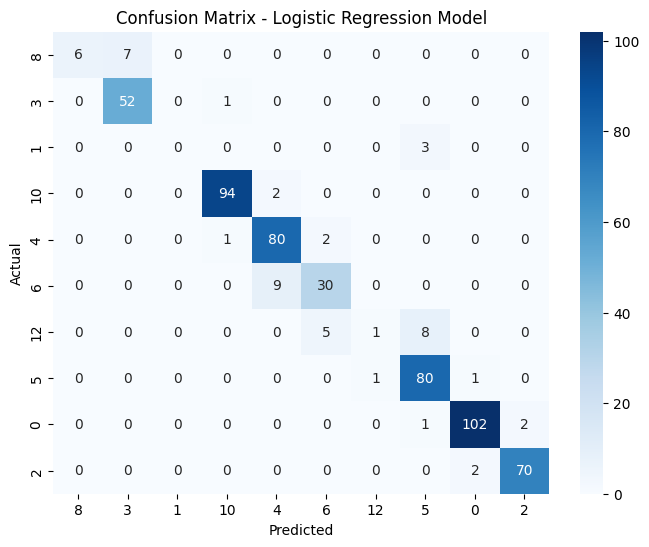

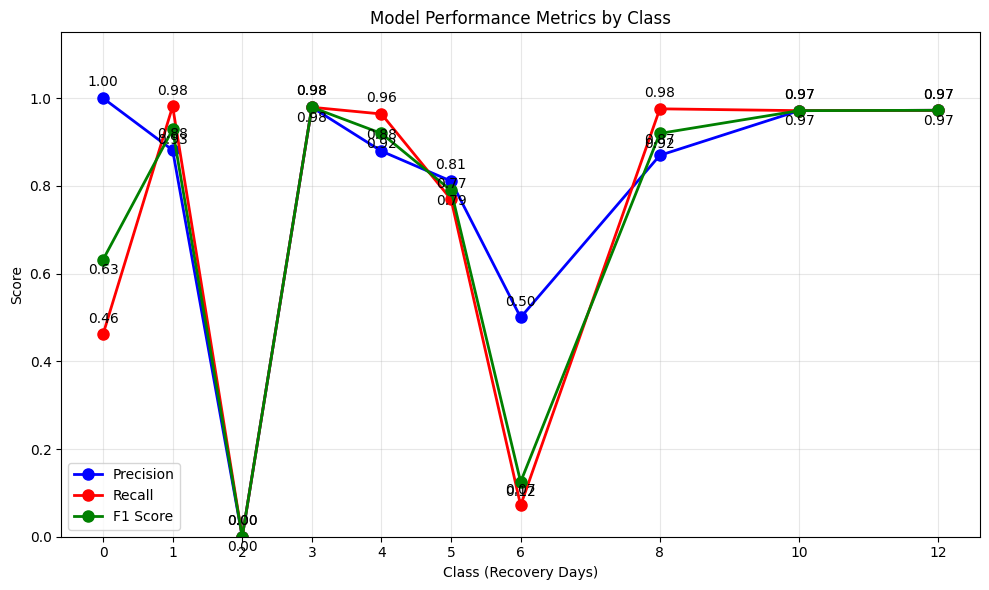

In [37]:
# Plot confusion matrix
from sklearn.metrics import f1_score, precision_score, recall_score


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Model')
plt.show()
def plot_combined_metrics(model, X_test, y_test):
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Get unique classes
    classes = np.unique(y_test)
    
    # Calculate metrics for each class
    precisions = []
    recalls = []
    f1_scores = []
    
    for class_label in classes:
        # Create binary classification for current class
        y_true_binary = (y_test == class_label).astype(int)
        y_pred_binary = (y_pred == class_label).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
        recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    # Create single plot
    plt.figure(figsize=(10, 6))
    
    # Plot all metrics
    plt.plot(classes, precisions, 'bo-', linewidth=2, markersize=8, label='Precision')
    plt.plot(classes, recalls, 'ro-', linewidth=2, markersize=8, label='Recall')
    plt.plot(classes, f1_scores, 'go-', linewidth=2, markersize=8, label='F1 Score')
    
    # Add value labels on points
    for metric, values, offset in zip(
        ['Precision', 'Recall', 'F1'], 
        [precisions, recalls, f1_scores],
        [0.02, 0.02, -0.04]  # Offset to prevent overlapping labels
    ):
        for i, v in enumerate(values):
            plt.text(classes[i], v + offset, f'{v:.2f}', 
                    ha='center', va='bottom')
    
    # Configure plot
    plt.xlabel('Class (Recovery Days)')
    plt.ylabel('Score')
    plt.title('Model Performance Metrics by Class')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, max(max(precisions), max(recalls), max(f1_scores)) * 1.15)  # Add 15% padding
    plt.xticks(classes)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Call the visualization function
plot_combined_metrics(recovery_model.model, X_test, y_test)

# Step 5: Deploying the Model and Making Predictions


In [38]:
model_path = 'stress_recovery_model_logistic_reg.joblib'
recovery_model.save_model(model_path)
print(f"Model saved to {model_path}")

Model saved to stress_recovery_model_logistic_reg.joblib
